In [0]:
%pip install tensorflow-cpu==2.12

Python interpreter will be restarted.
  Attempting uninstall: numpy
    Found existing installation: numpy 1.21.5
    Not uninstalling numpy at /databricks/python3/lib/python3.9/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-e8d18fa9-5b85-427d-93ee-3a08f1882a72
    Can't uninstall 'numpy'. No files were found to uninstall.
  Attempting uninstall: scipy
    Found existing installation: scipy 1.7.3
    Not uninstalling scipy at /databricks/python3/lib/python3.9/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-e8d18fa9-5b85-427d-93ee-3a08f1882a72
    Can't uninstall 'scipy'. No files were found to uninstall.
  Attempting uninstall: MarkupSafe
    Found existing installation: MarkupSafe 2.0.1
    Not uninstalling markupsafe at /databricks/python3/lib/python3.9/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-e8d18fa9-5b85-427d-93ee-3a08f1882a72
    Can't uninstall 'MarkupSafe'. No files were found to u

In [0]:
# Databricks-compatible version of original notebook

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense


In [0]:
past_days_to_predict_future = 60

In [0]:
# Enable inline plotting for notebooks
%matplotlib inline

df_train = spark.read.csv("dbfs:/FileStore/nvidia_stock_data_update.csv", header=True, inferSchema=True)
df_train_part2 = spark.read.csv("dbfs:/FileStore/nvidia_stock_data_test.csv", header=True, inferSchema=True)

# These are the correct paths
train = df_train.toPandas()
train_part2 = df_train_part2.toPandas()


In [0]:
train.tail()

,_c0,Date,Close_NVDA,High_NVDA,Low_NVDA,Open_NVDA,Volume_NVDA,Period_NVDA,Shares_Out_NVDA,Market_Cap_NVDA,...,PS_Ratio_NVDA,Total_Debt_NVDA,Cash_Equivalents_NVDA,TD_CE_Missing_NVDA,Shares_Out_Missing_NVDA,PE_Missing_NVDA,PS_Missing_NVDA,EV_NVDA,Daily_Change_%,Unusual_Activity
6534,6534,2025-01-13,133.217743,133.477729,129.498084,129.978051,204808900,after_trump,2.541310e+10,3.385476e+12,...,25.942939,1.105600e+10,7.280000e+09,0,0,0,0,3.389252e+12,-1.971901,False
6535,6535,2025-01-14,131.747879,136.367465,130.038045,136.037493,195590500,after_trump,2.541310e+10,3.348122e+12,...,25.656696,1.105600e+10,7.280000e+09,0,0,0,0,3.351898e+12,-1.103354,False
6536,6536,2025-01-15,136.227478,136.437450,131.277921,133.637705,185217300,after_trump,2.541310e+10,3.461962e+12,...,26.529057,1.105600e+10,7.280000e+09,0,0,0,0,3.465738e+12,3.400130,False
6537,6537,2025-01-16,133.557724,138.737240,133.477730,138.627250,209235600,after_trump,2.541310e+10,3.394116e+12,...,26.009147,1.105600e+10,7.280000e+09,0,0,0,0,3.397892e+12,-1.959776,False
6538,6538,2025-01-17,137.697342,138.487263,135.447549,136.677431,201188800,after_trump,2.497950e+10,3.439611e+12,...,26.357775,1.105600e+10,7.280000e+09,0,0,0,0,3.443387e+12,3.099497,False


In [0]:
train_part2.columns = ["Date", "Open_NVDA", "High_NVDA", "Low_NVDA", "Close_NVDA", "Volume_NVDA"]
train_part2.head()


,Date,Open_NVDA,High_NVDA,Low_NVDA,Close_NVDA,Volume_NVDA
0,2025-01-21,139.16,141.83,137.09,140.83,197748985.0
1,2025-01-22,144.66,147.79,143.67,147.07,237651395.0
2,2025-01-23,145.05,147.23,143.72,147.22,155915549.0
3,2025-01-24,148.37,148.97,141.88,142.62,234657635.0
4,2025-01-27,124.80,128.40,116.70,118.42,818830895.0


In [0]:
train_part2.shape

Out[24]: (77, 6)

In [0]:
train = pd.concat([train, train_part2[:47]], ignore_index=True)

In [0]:
train.tail()

,_c0,Date,Close_NVDA,High_NVDA,Low_NVDA,Open_NVDA,Volume_NVDA,Period_NVDA,Shares_Out_NVDA,Market_Cap_NVDA,...,PS_Ratio_NVDA,Total_Debt_NVDA,Cash_Equivalents_NVDA,TD_CE_Missing_NVDA,Shares_Out_Missing_NVDA,PE_Missing_NVDA,PS_Missing_NVDA,EV_NVDA,Daily_Change_%,Unusual_Activity
6581,NaN,2025-03-21,117.70,117.99,115.42,116.940,266498528.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6582,NaN,2025-03-24,121.41,122.22,119.34,119.880,228452534.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6583,NaN,2025-03-25,120.69,121.29,118.92,120.545,167447198.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6584,NaN,2025-03-26,113.76,118.84,112.71,118.730,296431667.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6585,NaN,2025-03-27,111.43,114.45,110.66,111.350,236902055.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [0]:
test = train_part2.iloc[-30:]

In [0]:
test.head()

,Date,Open_NVDA,High_NVDA,Low_NVDA,Close_NVDA,Volume_NVDA
47,2025-03-28,111.485,112.870,109.0701,109.67,229872549.0
48,2025-03-31,105.130,110.955,103.6500,108.38,299212653.0
49,2025-04-01,108.515,110.200,106.4700,110.15,222614034.0
50,2025-04-02,107.290,111.980,106.7900,110.42,220601243.0
51,2025-04-03,103.510,105.630,101.6000,101.80,338769412.0


In [0]:
train.shape

Out[29]: (6586, 23)

In [0]:
test.shape

Out[30]: (30, 6)

In [0]:
# making the training data only the values from the Open column.
training_set = train.iloc[:, 5:6].values
training_set

Out[31]: array([[4.01187826e-02],
       [4.05965509e-02],
       [4.20289016e-02],
       ...,
       [1.20545000e+02],
       [1.18730000e+02],
       [1.11350000e+02]])

In [0]:
training_set[0]

Out[32]: array([0.04011878])

In [0]:
# standardizing
sc = MinMaxScaler(feature_range=(0, 1))
training_set_scaled = sc.fit_transform(training_set)

In [0]:
training_set_scaled

Out[34]: array([[5.30717312e-05],
       [5.61947282e-05],
       [6.55574816e-05],
       ...,
       [7.87749462e-01],
       [7.75885470e-01],
       [7.27645106e-01]])

In [0]:
# play 60 values into one row to train the past 60 days for the following 60 days
X_train = []
y_train = []
for i in range(past_days_to_predict_future, len(train)):
    X_train.append(training_set_scaled[i-past_days_to_predict_future:i, 0]) # Select the timesteps of range i and select from the first column
    y_train.append(training_set_scaled[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)

In [0]:
X_train.shape

Out[36]: (6526, 60)

In [0]:
y_train.shape

Out[37]: (6526,)

In [0]:
print(len(X_train[3]))

60


In [0]:
X_train.shape

Out[39]: (6526, 60)

In [0]:
# need to reshape so that the input layer is proper for the RNN
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_train.shape

Out[40]: (6526, 60, 1)

In [0]:
# Creating the RNN model
model = Sequential()
model.add(SimpleRNN(past_days_to_predict_future,input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True))
model.add(SimpleRNN(past_days_to_predict_future))
model.add(Dense(1))

model.compile(optimizer = 'adam', loss = 'mean_squared_error')

model.fit(X_train, y_train, epochs = 30, batch_size = 64)

Epoch 1/30
102/102 [==============================] - 7s 42ms/step - loss: 0.0067
Epoch 2/30
102/102 [==============================] - 5s 47ms/step - loss: 1.7330e-04
Epoch 3/30
 94/102 [==========================>...] - ETA: 0s - loss: 1.2977e-04

*** WARNING: max output size exceeded, skipping output. ***

102/102 [==============================] - 4s 42ms/step - loss: 5.8731e-05
Epoch 28/30
102/102 [==============================] - 4s 44ms/step - loss: 5.1870e-05
Epoch 29/30
102/102 [==============================] - 4s 41ms/step - loss: 5.0414e-05
Epoch 30/30
102/102 [==============================] - 5s 47ms/step - loss: 5.7602e-05
Out[41]: <keras.callbacks.History at 0x7f8ccc50d400>

In [0]:
real_stock_price = test.iloc[:, 1:2].values
# Getting the predicted stock price
dataset_total = pd.concat((train["Open_NVDA"], test["Open_NVDA"]), axis = 0)
inputs = dataset_total[len(dataset_total) - len(test) - past_days_to_predict_future:].values

In [0]:
inputs.shape

Out[43]: (90,)

In [0]:
inputs = inputs.reshape(-1,1)
inputs.shape

Out[44]: (90, 1)

In [0]:
inputs = sc.transform(inputs)

In [0]:
len(test)

Out[46]: 30

In [0]:
X_test = []

# Creating timestamps
for i in range(past_days_to_predict_future, len(test)+past_days_to_predict_future):
    X_test.append(inputs[i-past_days_to_predict_future:i, 0])

X_test = np.array(X_test)

# Transforming 3D Features
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Final Predictions
predicted_stock_price = model.predict(X_test)


1/1 [==============================] - 1s 602ms/step


In [0]:
predicted_stock_price.shape

Out[48]: (30, 1)

In [0]:
# RESHAPE
predicted_stock_price = predicted_stock_price.reshape((predicted_stock_price.shape[0], -1))
predicted_stock_price.shape

Out[49]: (30, 1)

In [0]:
predicted_stock_price = sc.inverse_transform(predicted_stock_price)
predicted_stock_price

Out[50]: array([[109.29965 ],
       [109.0003  ],
       [ 99.374985],
       [103.16775 ],
       [105.5954  ],
       [ 98.65134 ],
       [ 98.98813 ],
       [ 85.38538 ],
       [ 98.782715],
       [ 96.12511 ],
       [104.381516],
       [106.85211 ],
       [111.84264 ],
       [110.47745 ],
       [105.67051 ],
       [100.84237 ],
       [ 98.63643 ],
       [ 97.12625 ],
       [101.873726],
       [103.82698 ],
       [103.88488 ],
       [107.33613 ],
       [101.932014],
       [101.85091 ],
       [108.68363 ],
       [111.11963 ],
       [110.63488 ],
       [110.10013 ],
       [110.77045 ],
       [113.96959 ]], dtype=float32)

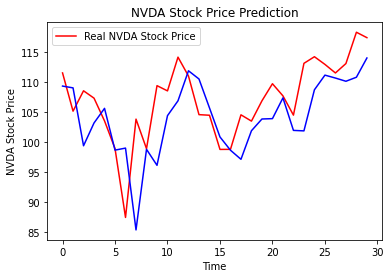

In [0]:
# Visualising the results
plt.plot(real_stock_price, color = 'red', label = 'Real NVDA Stock Price')
plt.plot(predicted_stock_price, color = 'blue')
plt.title('NVDA Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('NVDA Stock Price')
plt.legend()
plt.show()

In this graph, the blue line is the predicted stock of NVIDIA 
using our RNN model. 
While the red line is the actual NVIDIA stock. 
The graph indicates that our model is performing rather well, 
because the two lines are very similar and there's alot of 
overlap between them.